# Module 1 — Introduction to ASE: Building and Visualizing Atomic Structures

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USERNAME/qe-dft-course/blob/main/01_ase_structures.ipynb)

Learn to build molecules and crystals with the Atomic Simulation Environment (ASE), compare crystal structure types, and construct supercells and simple defects. **No DFT yet** — this notebook is pure structure-building intuition.

**Estimated time:** 30–45 min


**Learning objectives**
- Build molecules and bulk crystals as ASE `Atoms` objects
- Tell the difference between a primitive cell, a conventional cell, and a supercell
- Compare FCC, BCC, and diamond-cubic structures
- Compare a bent molecule (H₂O) to a linear one (CO₂)
- Build a simple point defect in a supercell


## Setup

This notebook only needs ASE — no DFT engine required yet.

In [1]:
!pip install -q ase


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 30.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import bulk, molecule, make_supercell
from ase.visualize.plot import plot_atoms

plt.rcParams['figure.dpi'] = 110


## Part 1 — Your first atoms: building molecules

An ASE `Atoms` object is just a list of chemical symbols plus 3D positions (and, for a periodic system, a cell). Let's build two triatomic molecules — water and carbon dioxide — and actually measure their geometry rather than assume it.

In [3]:
# molecule() builds well-known small molecules from ASE's built-in G2 database,
# using experimentally-informed reference geometries.
h2o = molecule('H2O')
co2 = molecule('CO2')

# get_angle(i, j, k) returns the angle at atom j, in degrees
h2o_angle = h2o.get_angle(1, 0, 2)  # O is index 0 in ASE's H2O template
co2_angle = co2.get_angle(1, 0, 2)  # C is index 0 in ASE's CO2 template

print(f'H2O bond angle: {h2o_angle:.1f} deg')
print(f'CO2 bond angle: {co2_angle:.1f} deg')


H2O bond angle: 104.0 deg
CO2 bond angle: 180.0 deg


Rotate these yourself before reading the angle as just a number.

In [4]:
from ase.visualize import view

# water
view(h2o, viewer='x3d')  # drag to rotate, scroll to zoom


In [5]:
from ase.visualize import view

# carbon dioxide
view(co2, viewer='x3d')  # drag to rotate, scroll to zoom


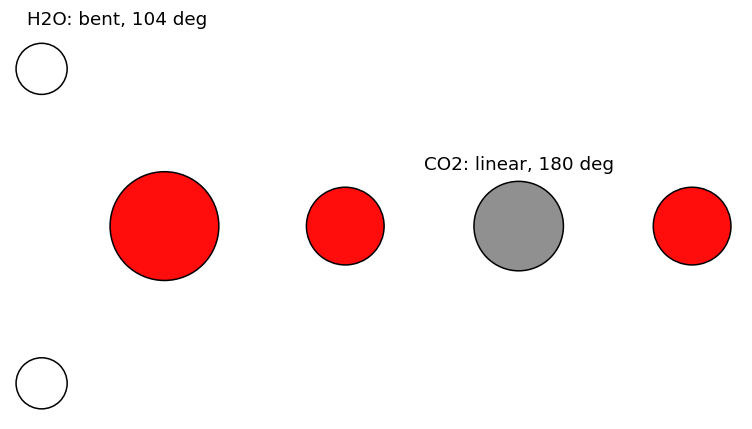

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_atoms(h2o, axes[0], radii=0.4, rotation=('0x,90y,0z'))
axes[0].set_title(f'H2O: bent, {h2o_angle:.0f} deg')
plot_atoms(co2, axes[1], radii=0.4, rotation=('0x,90y,0z'))
axes[1].set_title(f'CO2: linear, {co2_angle:.0f} deg')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


### Why is the shape of the two molecules different even though they both are symmetric about the central atom.

## Part 2 — Crystalline solids: FCC, BCC, and diamond-cubic

Now let's build three classic crystal structure types using three different elements: aluminum (FCC), iron (BCC), and silicon (diamond-cubic).

NOTE: `bulk()` returns the **primitive cell** by default — the smallest repeating unit — not the conventional cubic cell you might be more familiar with.

In [7]:
al = bulk('Al', 'fcc', a=4.05)      # aluminum, FCC
fe = bulk('Fe', 'bcc', a=2.87)      # iron, BCC
si = bulk('Si', 'diamond', a=5.43)  # silicon, diamond-cubic

for name, atoms in [('Al (FCC)', al), ('Fe (BCC)', fe), ('Si (diamond)', si)]:
    print(f'{name}: {len(atoms)} atom(s) in the primitive cell, '
          f'cell volume = {atoms.get_volume():.2f} A^3')


Al (FCC): 1 atom(s) in the primitive cell, cell volume = 16.61 A^3
Fe (BCC): 1 atom(s) in the primitive cell, cell volume = 11.82 A^3
Si (diamond): 2 atom(s) in the primitive cell, cell volume = 40.03 A^3


In [11]:
al

Atoms(symbols='Al', pbc=True, cell=[[0.0, 2.025, 2.025], [2.025, 0.0, 2.025], [2.025, 2.025, 0.0]])

In [12]:
fe

Atoms(symbols='Fe', pbc=True, cell=[[-1.435, 1.435, 1.435], [1.435, -1.435, 1.435], [1.435, 1.435, -1.435]], initial_magmoms=...)

In [13]:
si

Atoms(symbols='Si2', pbc=True, cell=[[0.0, 2.715, 2.715], [2.715, 0.0, 2.715], [2.715, 2.715, 0.0]])

### Note: See how the lattice parameters values we gave as input are different from the actual lattice parameters of the cell constructed by the ASE module. This is because of construction of the primitive cell.

### PBC=Periodic boundary condition

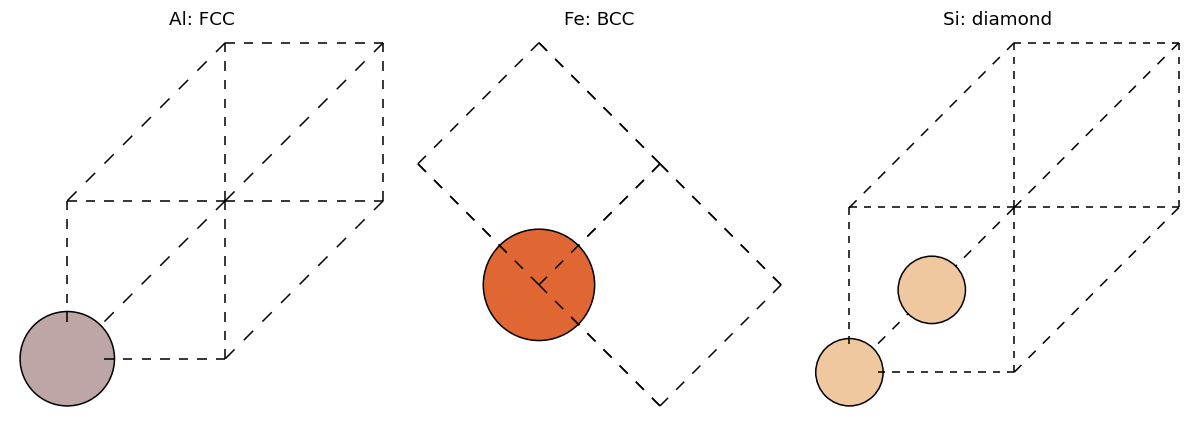

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (name, atoms) in zip(axes, [('Al: FCC', al), ('Fe: BCC', fe), ('Si: diamond', si)]):
    plot_atoms(atoms, ax, radii=0.5, show_unit_cell=2)
    ax.set_title(name)
    ax.set_axis_off()
plt.tight_layout()
plt.show()


Interactive views of the same three (edit `al`/`fe`/`si` below to look at any of them):

In [9]:
from ase.visualize import view

# swap in al or fe to look at those instead
view(si, viewer='x3d')  # drag to rotate, scroll to zoom


In [10]:
si

Atoms(symbols='Si2', pbc=True, cell=[[0.0, 2.715, 2.715], [2.715, 0.0, 2.715], [2.715, 2.715, 0.0]])

In [14]:
# Now let's look at the CONVENTIONAL (cubic) cells instead, using cubic=True.
# These are bigger but easier to recognize.
al_conv = bulk('Al', 'fcc', a=4.05, cubic=True)
fe_conv = bulk('Fe', 'bcc', a=2.87, cubic=True)
si_conv = bulk('Si', 'diamond', a=5.43, cubic=True)

print('Primitive vs. conventional atom counts:')
print(f'  Al: {len(al)} -> {len(al_conv)}')
print(f'  Fe: {len(fe)} -> {len(fe_conv)}')
print(f'  Si: {len(si)} -> {len(si_conv)}')


Primitive vs. conventional atom counts:
  Al: 1 -> 4
  Fe: 1 -> 2
  Si: 2 -> 8


Question: Silicon's diamond-cubic structure is built from an FCC lattice, yet the conventional cell holds 8 atoms rather than the 4 you'd expect from FCC alone. What's the distinction between a crystal's *lattice* and its *basis*?

In [16]:
from ase.visualize import view

# swap in al or fe to look at those instead
view(fe_conv, viewer='x3d')  # drag to rotate, scroll to zoom


In [17]:
# swap in al or fe to look at those instead
view(al_conv, viewer='x3d')  # drag to rotate, scroll to zoom


### How much of the cell is actually occupied?

Atom *count* per cell is only part of the story — FCC, BCC, and diamond also pack their atoms with very different efficiency. Let's compute the **atomic packing fraction**: the fraction of each cell's volume that's actually occupied by (touching, hard-sphere) atoms.

In [18]:
# Atomic radii for touching hard spheres along the relevant close-packed
# direction (NOT the tabulated atomic radius -- it's whatever radius makes
# neighboring atoms just touch, given each structure's geometry).
structures = {
    'Al (FCC)':      (al,  4.05 * np.sqrt(2) / 4),   # atoms touch along face diagonal
    'Fe (BCC)':      (fe,  2.87 * np.sqrt(3) / 4),   # atoms touch along body diagonal
    'Si (diamond)':  (si,  5.43 * np.sqrt(3) / 8),   # atoms touch along the bonded direction
}

for name, (atoms, radius) in structures.items():
    n_atoms = len(atoms)
    atom_volume = n_atoms * (4 / 3) * np.pi * radius**3
    packing_fraction = atom_volume / atoms.get_volume()
    print(f'{name:15s}: {packing_fraction:.1%} of the cell volume is occupied')


Al (FCC)       : 74.0% of the cell volume is occupied
Fe (BCC)       : 68.0% of the cell volume is occupied
Si (diamond)   : 34.0% of the cell volume is occupied


## Part 3 — Supercells

A supercell is just a periodic repetition of a smaller cell. We'll need these constantly in later notebooks — for convergence testing, defects, surfaces, and interfaces.

2x2x2 Al supercell: 8 atoms (expected 8)


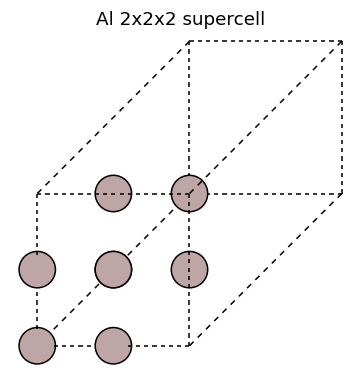

In [19]:
# The simplest way: repeat(nx, ny, nz) tiles the cell uniformly.
al_222 = al.repeat((2, 2, 2))
print(f'2x2x2 Al supercell: {len(al_222)} atoms '
      f'(expected {len(al) * 8})')

fig, ax = plt.subplots(figsize=(4, 4))
plot_atoms(al_222, ax, radii=0.4, show_unit_cell=2)
ax.set_title('Al 2x2x2 supercell')
ax.set_axis_off()
plt.show()


In [21]:
from ase.visualize import view

# the 2x2x2 Al supercell
view(al_222, viewer='x3d')  # drag to rotate, scroll to zoom


1x1x3 Si supercell: 6 atoms


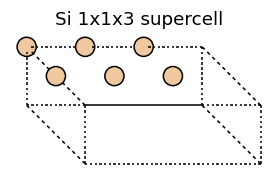

In [22]:
# Supercells don't have to be uniform. A 1x1x3 supercell only extends
# along one direction -- useful later for slabs, interfaces, or
# separating periodic images of a defect along one axis only.
si_113 = si.repeat((1, 1, 3))
print(f'1x1x3 Si supercell: {len(si_113)} atoms')

fig, ax = plt.subplots(figsize=(3, 6))
plot_atoms(si_113, ax, radii=0.4, show_unit_cell=2, rotation='90x')
ax.set_title('Si 1x1x3 supercell')
ax.set_axis_off()
plt.show()


## Part 4 — A simple manipulation: a point defect

Let's build a silicon vacancy: take a supercell, delete one atom, and look at how the local symmetry around the hole is broken.

Perfect 2x2x2 Si supercell: 16 atoms
With one vacancy:          15 atoms


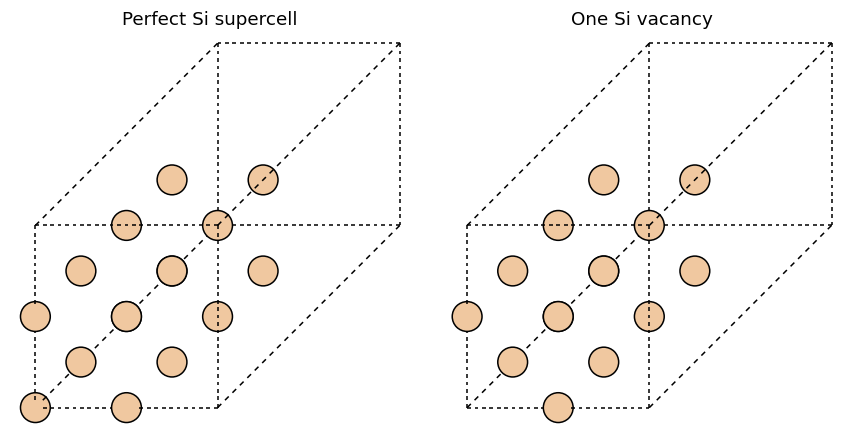

In [23]:
si_defect = si.repeat((2, 2, 2))
del si_defect[0]  # remove one Si atom -> a vacancy
print(f'Perfect 2x2x2 Si supercell: {len(si.repeat((2,2,2)))} atoms')
print(f'With one vacancy:          {len(si_defect)} atoms')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_atoms(si.repeat((2, 2, 2)), axes[0], radii=0.4, show_unit_cell=2)
axes[0].set_title('Perfect Si supercell')
plot_atoms(si_defect, axes[1], radii=0.4, show_unit_cell=2)
axes[1].set_title('One Si vacancy')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


In [24]:
# A substitutional defect instead: swap one Si atom for Ge (same group,
# similar chemistry, different size) rather than deleting it.
si_ge = si.repeat((2, 2, 2))
si_ge[0].symbol = 'Ge'
print(si_ge.get_chemical_formula())


GeSi15


In [26]:
from ase.visualize import view

# the structure with a vacancy
view(si_ge, viewer='x3d')  # drag to rotate, scroll to zoom


> **🤔 Think About It**
>
> Vacancies and substitutions both break the perfect crystal's symmetry locally. Which one do you expect to distort the neighboring atoms' positions more, and why?

## Part 5 — Saving and re-loading structures

In practice you'll often want to save a structure and reload it later (or hand it to a DFT code). ASE reads/writes many formats through the same two functions.

In [27]:
from ase.io import write, read

write('al.cif', al)
write('h2o.xyz', h2o)

al_reloaded = read('al.cif')
print(al_reloaded)


Atoms(symbols='Al', pbc=True, cell=[[2.8637824638055176, 0.0, 0.0], [1.4318912319027586, 2.4801083645679682, 0.0], [1.4318912319027586, 0.8267027881893226, 2.3382685902179845]], spacegroup_kinds=...)


## Discuss / Explain

Answer using what you actually observed while building and visualizing these structures in this notebook.

1. Why is the shape of the H2O and the CO2 molecules different even though they both are symmetric about the central atom.
2. Why is the diamond-cubic structure so much less densely packed than FCC or BCC, even though every atom is still bonded to its nearest neighbors? (Use your packing-fraction numbers and the bond-angle hint from the question above.)
3. You built both a primitive cell and a conventional cell for the same physical crystal. In what sense are they 'the same crystal' despite having different numbers of atoms in the box ASE reports?
4. When you built the silicon vacancy, only the neighbors immediately around the missing atom moved (conceptually — we didn't relax positions here, but imagine we had). Why would a *larger* supercell be necessary if you wanted the vacancy's effect to be 'diluted' rather than interacting with its own periodic images?


## Assignment Exercises

Build and visualize the following structures. For each, report the number of atoms in the primitive cell. Also, answer the associated questions.

1. **NaCl (rock salt)** — a binary ionic crystal with a 2-atom basis with a=5.64 A. How does its structure relate to the FCC lattice you already built for Al?
2. **BaTiO₃ (perovskite)** — a 5-atom-basis structure important in ferroelectrics (you'll need to build this one by hand with `Atoms(...)`, since it isn't one of `bulk()`'s built-in prototypes. Hint: look up the standard cubic perovskite fractional coordinates for Ba, Ti, and the 3 O atoms).
3. **A random substitutional alloy** — start from a Cu FCC supercell and randomly replace ~20% of the Cu atoms with Ni. Visualize it. Does it still look like a 'crystal' to you?


## Summary

You can now build molecules and crystals, tell primitive cells apart from conventional cells and supercells, and make a simple defect. These structures will be used later as input to DFT codes to compute energies of these systems.

**Next:** Module 2 will be about running DFT computations for molecules.

## References

- Larsen, A. H. et al. *The Atomic Simulation Environment — a Python library for working with atoms*. J. Phys.: Condens. Matter 29, 273002 (2017). https://wiki.fysik.dtu.dk/ase/